In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
c
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
data = pd.read_csv("/content/diabetes.csv")

In [ ]:
print(data)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [ ]:

columns_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_fix:
    median_value = data[col][data[col] != 0].median()
    data[col] = data[col].replace(0, median_value)
print("\nDescriptive Statistics After Cleaning:")
print(data.describe())
print(data)



Descriptive Statistics After Cleaning:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.4769

In [ ]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)#153.8 test rows


In [ ]:
# 1. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 70.13%


In [ ]:
print("\nLogistic Regression - Confusion Matrix:")
cm = confusion_matrix(y_test, logistic_predictions)
print(cm)

true_negative, false_positive, false_negative, true_positive = cm.ravel()
print("\nPerformance Metrics:")
print(f"True Positives (TP): {true_positive}")
print(f"False Positives (FP): {false_positive}")
print(f"True Negatives (TN): {true_negative}")
print(f"False Negatives (FN): {false_negative}")

print("\nLogistic Regression - Classification Report:")
report = classification_report(y_test, logistic_predictions)
print(report)


Logistic Regression - Confusion Matrix:
[[81 19]
 [27 27]]

Performance Metrics:
True Positives (TP): 27
False Positives (FP): 19
True Negatives (TN): 81
False Negatives (FN): 27

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [ ]:
# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 67.53%


In [ ]:
print("\nKNN - Confusion Matrix:")
cm = confusion_matrix(y_test, knn_predictions)
print(cm)

true_negative, false_positive, false_negative, true_positive = cm.ravel()
print("\nPerformance Metrics:")
print(f"True Positives (TP): {true_positive}")
print(f"False Positives (FP): {false_positive}")
print(f"True Negatives (TN): {true_negative}")
print(f"False Negatives (FN): {false_negative}")

print("\nKNN - Classification Report:")
report = classification_report(y_test, knn_predictions)
print(report)


KNN - Confusion Matrix:
[[77 23]
 [27 27]]

Performance Metrics:
True Positives (TP): 27
False Positives (FP): 23
True Negatives (TN): 77
False Negatives (FN): 27

KNN - Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       100
           1       0.54      0.50      0.52        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154



In [ ]:
# 3. Naive Bayes
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train, y_train)
naive_bayes_predictions = naive_bayes_model.predict(X_test)
naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_predictions)
print(f"Naive Bayes Accuracy: {naive_bayes_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 70.13%


In [ ]:
print("\nNaive Bayes - Confusion Matrix:")
cm = confusion_matrix(y_test, naive_bayes_predictions)
print(cm)

true_negative, false_positive, false_negative, true_positive = cm.ravel()
print("\nPerformance Metrics:")
print(f"True Positives (TP): {true_positive}")
print(f"False Positives (FP): {false_positive}")
print(f"True Negatives (TN): {true_negative}")
print(f"False Negatives (FN): {false_negative}")

print("\nNaive Bayes - Classification Report:")
report = classification_report(y_test, naive_bayes_predictions)
print(report)


Naive Bayes - Confusion Matrix:
[[74 26]
 [20 34]]

Performance Metrics:
True Positives (TP): 34
False Positives (FP): 26
True Negatives (TN): 74
False Negatives (FN): 20

Naive Bayes - Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



In [ ]:
# 4. Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
decision_tree_predictions = decision_tree_model.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
print(f"Decision Tree Accuracy: {decision_tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 68.18%



Decision Tree - Confusion Matrix:
[[79 21]
 [28 26]]

Performance Metrics:
True Positives (TP): 26
False Positives (FP): 21
True Negatives (TN): 79
False Negatives (FN): 28

Decision Tree - Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



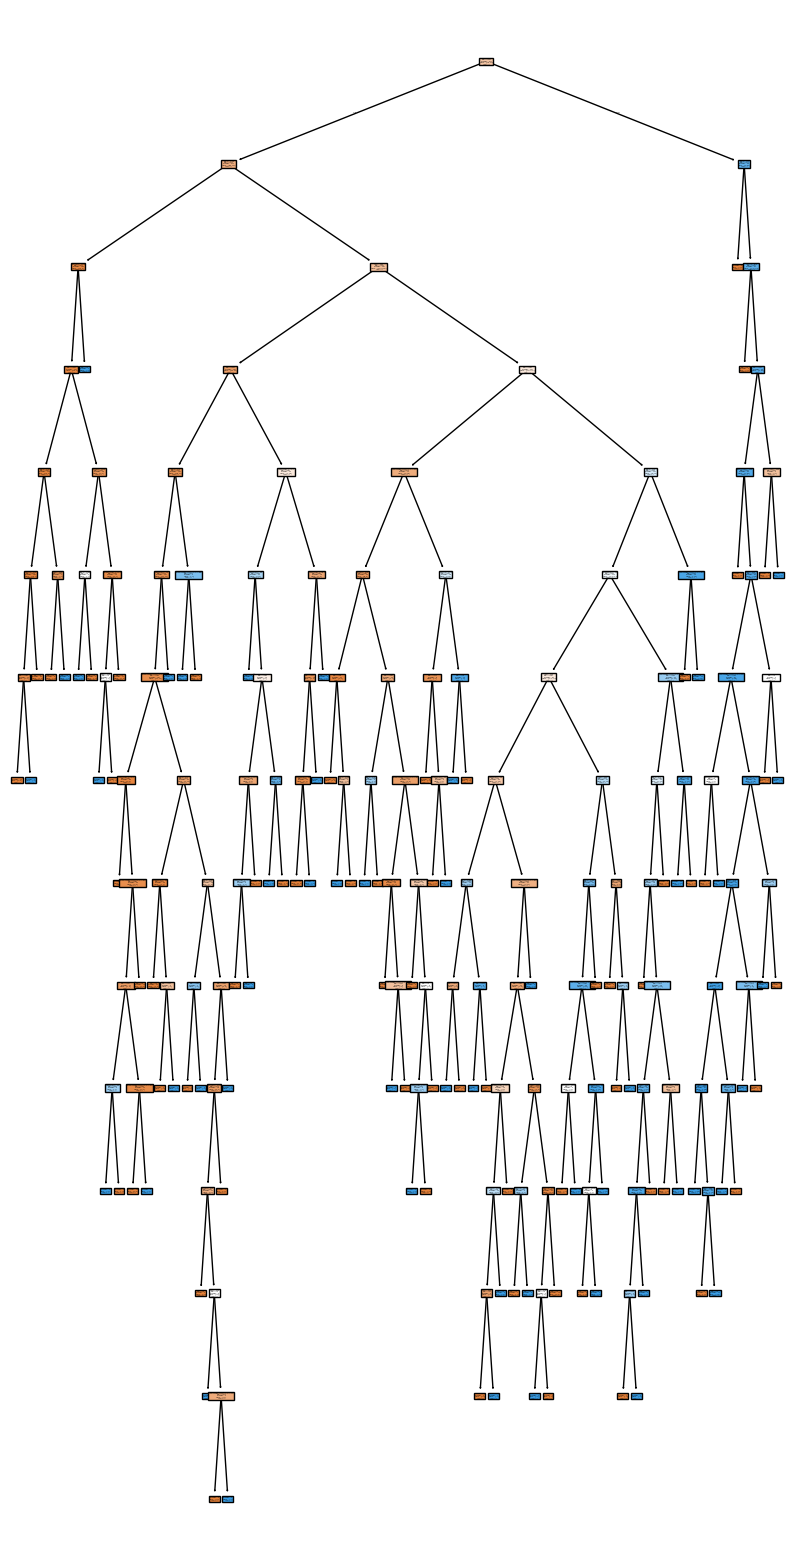

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
print("\nDecision Tree - Confusion Matrix:")
cm = confusion_matrix(y_test, decision_tree_predictions)
print(cm)

true_negative, false_positive, false_negative, true_positive = cm.ravel()
print("\nPerformance Metrics:")
print(f"True Positives (TP): {true_positive}")
print(f"False Positives (FP): {false_positive}")
print(f"True Negatives (TN): {true_negative}")
print(f"False Negatives (FN): {false_negative}")

print("\nDecision Tree - Classification Report:")
report = classification_report(y_test, decision_tree_predictions)
print(report)
plt.figure(figsize=(10, 20))
plot_tree(decision_tree_model, filled=True, feature_names=X.columns, class_names=["0", "1"])
plt.show()

In [ ]:
from sklearn.tree import export_text
rules = export_text(decision_tree_model, feature_names=list(X.columns))
print("Decision Tree Rules:")
print(tree_rules)


Decision Tree Rules:
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- Glucose <= 133.50
|   |   |   |   |--- BMI <= 26.90
|   |   |   |   |   |--- Insulin <= 48.50
|   |   |   |   |   |   |--- Insulin <= 47.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Insulin >  47.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Insulin >  48.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  26.90
|   |   |   |   |   |--- Age <= 44.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Age >  44.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- Glucose >  133.50
|   |   |   |   |--- Glucose <= 134.50
|   |   |   |   |   |--- BMI <= 24.85
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BMI >  24.85
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Glucose >  134.50
|   |   |   |   |   |--- BloodPressure <= 56.00
|   |   |   |   |   |   |--- Age <= 4